<a href="https://colab.research.google.com/github/sankeawthong/Project-1-Lita-Chatbot/blob/main/Lab09_KMeans%20Clustering%20(Assignment).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 9 — Groups Nobody Labelled

**Machine Learning (3 credits, 2-2-5) · Week 9 · School of Information Technology**

| | |
|---|---|
| **Time budget** | ~2 hours (in-lab) |
| **Learning objectives** | 1. Run K-Means correctly — scaling, seeding, `n_init` — and explain each step of Lloyd's algorithm — 2. Choose K from the elbow, the silhouette and the cluster sizes together — 3. Profile clusters and turn them into named, usable segments — 4. Recognise when a clustering result should not be trusted|
| **Dataset** | Retail customers (synthetic, 540 rows, 5 numeric features, built here) — no label column, on purpose |
| **Grading** | Exercises 1–6 + AI-usage disclosure · self-checks give instant feedback |

> **Today there is no `y`.** No accuracy, no confusion matrix, no test set to check against. K-Means will always hand you K groups — your job today is to decide whether they **mean** anything. Everything in this lab is about building that judgement.

**First:** File → Save a copy in Drive, rename to `Lab9_<your_student_id>`.

---
## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, adjusted_rand_score

RNG_SEED = 42
np.random.seed(RNG_SEED)
print("Setup complete ✔")

Setup complete ✔


---
## Part 1 · Meet the customers — and look before you cluster

A retail chain wants to group its customers so marketing can treat each group differently. We'll build the customer table here, so everyone has identical data and nothing to download.

| column | meaning |
|---|---|
| `age` | years |
| `annual_income` | baht per year |
| `spend_per_visit` | average basket, baht |
| `visits_per_month` | how often they come |
| `recency_days` | days since the last visit |
| `preferred_channel` | app / web / in-store — *for profiling only, not for clustering* |

There is **no segment column**. That is not an oversight; it is the problem.

In [2]:
def make_customer_data(seed=42):
    """Generate the customer table. Deterministic — everyone gets the same 540 rows."""
    rng = np.random.RandomState(seed)
    # (n, age, spend_per_visit, visits_per_month, recency_days)
    segments = [
        (150, (24, 4.0), (165, 38),    (10.5, 1.4), (6, 3)),
        (120, (52, 7.0), (2100, 380),  (1.4, 0.5),  (24, 8)),
        (160, (40, 5.5), (820, 150),   (4.0, 0.9),  (11, 4)),
        (110, (41, 11.0), (430, 130),  (0.6, 0.3),  (118, 26)),
    ]
    rows, hidden = [], []
    for i, (n, age, spv, vpm, rec) in enumerate(segments):
        rows.append(np.column_stack([
            rng.normal(age[0], age[1], n).clip(18, 78),
            rng.normal(46000, 11000, n).clip(15000, 95000),   # income: same for everyone
            rng.normal(spv[0], spv[1], n).clip(60, None),
            rng.normal(vpm[0], vpm[1], n).clip(0.1, None),
            rng.normal(rec[0], rec[1], n).clip(1, None),
        ]))
        hidden += [i] * n
    X = np.vstack(rows); hidden = np.array(hidden)
    order = rng.permutation(len(X))
    X, hidden = X[order], hidden[order]

    df = pd.DataFrame(X, columns=["age", "annual_income", "spend_per_visit",
                                  "visits_per_month", "recency_days"])
    df["age"] = df["age"].round(0).astype(int)
    df["annual_income"] = (df["annual_income"] / 100).round(0).astype(int) * 100
    df["spend_per_visit"] = df["spend_per_visit"].round(0).astype(int)
    df["visits_per_month"] = df["visits_per_month"].round(2)
    df["recency_days"] = df["recency_days"].round(0).astype(int)
    df["preferred_channel"] = np.where(hidden == 0, rng.choice(["app","app","in-store"], len(df)),
                              np.where(hidden == 1, rng.choice(["in-store","in-store","web"], len(df)),
                              np.where(hidden == 2, rng.choice(["app","web","in-store"], len(df)),
                                                    rng.choice(["web","in-store"], len(df)))))
    df.insert(0, "customer_id", [f"C{1000+i}" for i in range(len(df))])
    return df, hidden


customers, _hidden_truth = make_customer_data(RNG_SEED)
FEATURES = ["age", "annual_income", "spend_per_visit", "visits_per_month", "recency_days"]
X_raw = customers[FEATURES].to_numpy(float)

print(f"{len(customers)} customers, {len(FEATURES)} numeric features\n")
customers.head()

540 customers, 5 numeric features



,customer_id,age,annual_income,spend_per_visit,visits_per_month,recency_days,preferred_channel
0,C1000,48,38400,2541,1.29,24,web
1,C1001,61,42500,566,0.74,165,in-store
2,C1002,37,52400,748,4.53,13,app
3,C1003,24,34200,168,8.25,6,app
4,C1004,42,55400,1021,3.95,13,in-store


In [3]:
summary = customers[FEATURES].describe().T[["mean", "std", "min", "max"]]
summary["range"] = summary["max"] - summary["min"]
print(summary.round(1).to_string())

share = X_raw.var(axis=0) / X_raw.var(axis=0).sum()
print("\nShare of the total variance, per feature (raw units):")
for f, s in zip(FEATURES, share):
    print(f"  {f:17s} {s:7.2%}  " + "█" * int(round(s * 40)))

                     mean      std      min      max    range
age                  38.9     12.6     18.0     70.0     52.0
annual_income     46771.3  10986.6  15000.0  88400.0  73400.0
spend_per_visit     854.9    763.7     84.0   2914.0   2830.0
visits_per_month      4.5      3.9      0.1     14.8     14.7
recency_days         34.3     44.6      1.0    165.0    164.0

Share of the total variance, per feature (raw units):
  age                 0.00%  
  annual_income      99.52%  ████████████████████████████████████████
  spend_per_visit     0.48%  
  visits_per_month    0.00%  
  recency_days        0.00%  


**Read the last block before you go any further.** K-Means measures Euclidean distance, and distance is dominated by whichever feature has the biggest numbers. Here `annual_income` runs into the tens of thousands while `visits_per_month` runs from 0 to 15 — so income carries **over 99%** of the variance.

On raw data, "close together" would mean "similar income" and almost nothing else. Whether that is what we want depends on whether income actually separates these customers. Let's find out.

---
## Part 2 · Raw vs scaled — the same algorithm, two different answers

We fit the identical model, `KMeans(n_clusters=4)`, twice: once on raw values and once after `StandardScaler`, which puts every feature on mean 0, standard deviation 1.

In [4]:
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

km_raw    = KMeans(n_clusters=4, n_init=10, random_state=RNG_SEED).fit(X_raw)
km_scaled = KMeans(n_clusters=4, n_init=10, random_state=RNG_SEED).fit(X_scaled)

def profile(labels):
    # mean of each feature per cluster, plus the cluster size
    p = customers.assign(cluster=labels).groupby("cluster")[FEATURES].mean().round(1)
    p["size"] = np.bincount(labels)
    return p

print("RAW — cluster profiles")
print(profile(km_raw.labels_).to_string())
print("\nSCALED — cluster profiles")
print(profile(km_scaled.labels_).to_string())

RAW — cluster profiles
          age  annual_income  spend_per_visit  visits_per_month  recency_days  size
cluster                                                                            
0        39.2        41400.6            883.7               4.5          31.9   168
1        40.6        63051.6            974.0               4.1          34.5    91
2        38.0        51408.9            802.2               4.7          36.3   191
3        38.3        30493.3            792.6               4.5          34.3    90

SCALED — cluster profiles
          age  annual_income  spend_per_visit  visits_per_month  recency_days  size
cluster                                                                            
0        41.1        46811.8            428.9               0.6         118.4   110
1        23.7        46815.3            167.1              10.4           5.9   150
2        53.2        47613.6           2165.4               1.4          24.1   118
3        40.9        46089

In [5]:
# Only possible because this dataset is synthetic: we secretly know the real segments.
# (In real work there is no such column — that is why the rest of the lab exists.)
print(f"agreement with the real segments (ARI, 1 = perfect, 0 = chance)")
print(f"  raw    : {adjusted_rand_score(_hidden_truth, km_raw.labels_):.3f}")
print(f"  scaled : {adjusted_rand_score(_hidden_truth, km_scaled.labels_):.3f}")

agreement with the real segments (ARI, 1 = perfect, 0 = chance)
  raw    : 0.000
  scaled : 0.990


**Look at the `annual_income` column in each table.**

- **Raw:** the four clusters are four **income bands**, and every other column is nearly identical across them. K-Means did exactly what it was told — it found the direction with the largest numbers — and it found nothing useful, because in this data income is the same for every type of customer. Agreement with the real segments: **0.00**.
- **Scaled:** income is now flat across the clusters, and the *behaviour* columns separate sharply — visits, basket size, recency. Agreement: **0.99**.

Same data, same algorithm, same K. The only difference was one line of preprocessing.

> **Scaling is not optional for K-Means.** If your features are in different units, scale them — and say so in your report.

---
## Part 3 · Lloyd's algorithm from scratch

`.fit()` is about to stop being magic again (remember gradient descent in Lab 6). K-Means is two steps, repeated:

1. **Assign** — every point joins its nearest centroid.
2. **Update** — every centroid moves to the mean of its points.

Stop when the centroids stop moving.

In [6]:
def lloyd(X, k, seed=0, max_iter=100):
    # Plain K-Means. Returns (labels, centroids, inertia_history).
    rng = np.random.default_rng(seed)
    centroids = X[rng.choice(len(X), k, replace=False)]          # start: k random points
    history = []
    for _ in range(max_iter):
        d2 = ((X[:, None, :] - centroids[None, :, :]) ** 2).sum(axis=2)   # squared distances, n × k
        labels = d2.argmin(axis=1)                                 # 1. ASSIGN to the nearest
        history.append(d2.min(axis=1).sum())                       #    (record inertia)
        new = np.array([X[labels == j].mean(axis=0) for j in range(k)])   # 2. UPDATE to the mean
        if np.allclose(new, centroids):                            # 3. nothing moved → stop
            break
        centroids = new
    return labels, centroids, history

my_labels, my_centroids, history = lloyd(X_scaled, k=4, seed=7)

print(f"iterations      : {len(history)}")
print(f"inertia history : {np.round(history, 1)}")
print(f"our inertia     : {history[-1]:.1f}")
print(f"sklearn inertia : {km_scaled.inertia_:.1f}")
print(f"same partition as sklearn? ARI = {adjusted_rand_score(km_scaled.labels_, my_labels):.3f}")

iterations      : 9
inertia history : [1559.3  926.9  897.5  883.6  866.6  837.6  804.7  800.3  800.2]
our inertia     : 800.2
sklearn inertia : 800.2
same partition as sklearn? ARI = 1.000


**About fifteen lines, and it reached the same answer as scikit-learn.** Now look at the inertia history: it goes **down at every iteration and never up**. That is not luck:

- *Assign* only ever moves a point to a **nearer** centroid, so no distance grows.
- *Update* puts each centroid at the **mean**, and the mean is exactly the point that minimises squared distance.

So inertia can only fall, and it cannot fall below zero — which is why the loop is guaranteed to stop. What it does **not** guarantee is that it stops at the *best* answer. That is Part 4.

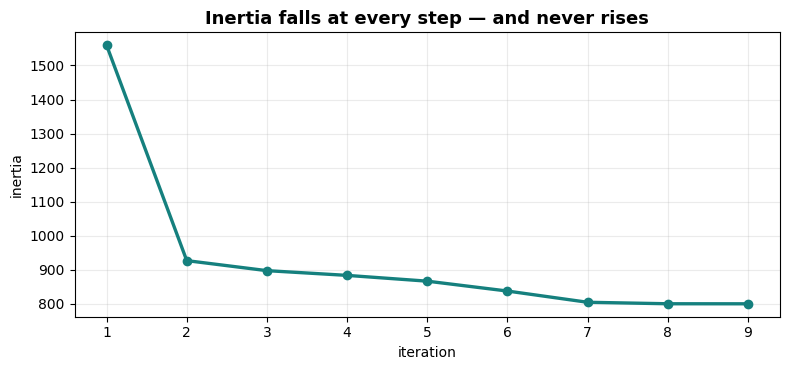

In [7]:
fig, ax = plt.subplots(figsize=(8, 3.8))
ax.plot(range(1, len(history) + 1), history, marker="o", lw=2.4, color="#15807E")
ax.set_xlabel("iteration"); ax.set_ylabel("inertia")
ax.set_title("Inertia falls at every step — and never rises", fontsize=13, fontweight="bold")
ax.grid(alpha=.25); plt.tight_layout(); plt.show()

---
## Part 4 · The seeding problem, and the fix

Lloyd's algorithm stops at the nearest **local** optimum. A bad start can leave it stuck. We run 20 single starts with **random** seeding and 20 with **K-Means++** seeding, and compare where each one lands.

                 0      1      2      3      4      5      6      7      8      9      10     11     12     13     14     15      16      17      18      19
random start  800.2  800.2  800.2  800.2  800.2  800.2  800.2  800.2  800.2  800.2  800.2  800.2  800.2  800.2  800.2  800.2  1044.5  1045.9  1147.8  1147.9
k-means++     800.2  800.2  800.2  800.2  800.2  800.2  800.2  800.2  800.2  800.2  800.2  800.2  800.2  800.2  800.2  800.2   800.2   800.2   800.2  1045.8


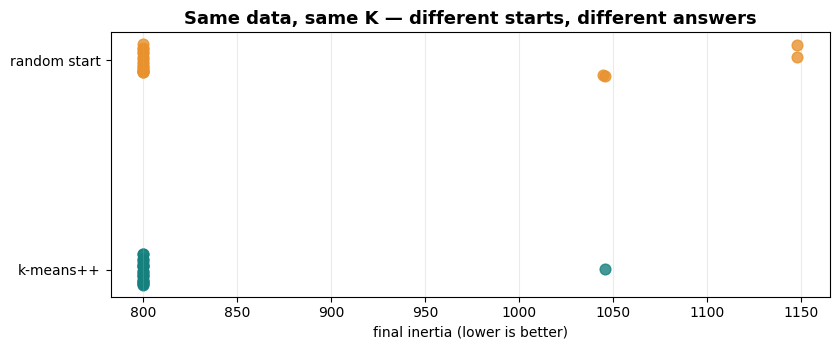

In [8]:
random_inertias = [KMeans(4, init="random",    n_init=1, random_state=s).fit(X_scaled).inertia_ for s in range(20)]
pp_inertias     = [KMeans(4, init="k-means++", n_init=1, random_state=s).fit(X_scaled).inertia_ for s in range(20)]

seed_table = pd.DataFrame({"random start": np.round(sorted(random_inertias), 1),
                           "k-means++":    np.round(sorted(pp_inertias), 1)})
print(seed_table.T.to_string())

fig, ax = plt.subplots(figsize=(8.5, 3.6))
ax.scatter(random_inertias, np.full(20, 1) + np.random.uniform(-.08, .08, 20), s=60, color="#E8912D", alpha=.8)
ax.scatter(pp_inertias,     np.full(20, 0) + np.random.uniform(-.08, .08, 20), s=60, color="#15807E", alpha=.8)
ax.set_yticks([0, 1]); ax.set_yticklabels(["k-means++", "random start"])
ax.set_xlabel("final inertia (lower is better)")
ax.set_title("Same data, same K — different starts, different answers", fontsize=13, fontweight="bold")
ax.grid(alpha=.25, axis="x"); plt.tight_layout(); plt.show()

**Most starts reach the same best inertia (about 800) — but not all.** A few random starts get stuck around 1,045–1,148, which means two real segments merged and another one got split. K-Means++ spreads the starting centroids apart, so it gets stuck less often — but even it is not perfect.

That is why scikit-learn's default is **K-Means++ seeding plus several restarts** (`n_init`), keeping the run with the lowest inertia. One unlucky start is a real risk; ten restarts make it negligible.

> In your report: state `init`, `n_init` and `random_state`. Otherwise nobody — including you next month — can reproduce your clusters.

---
## Part 5 · Choosing K — the elbow, the silhouette, and the sizes

We have used K = 4 so far because we were told to. Now we pretend we don't know, and look at the evidence for K = 2 … 8.

 K  inertia  silhouette  smallest cluster
 2   1690.5       0.369               152
 3   1111.4       0.431               110
 4    800.2       0.435               110
 5    681.0       0.404                76
 6    616.4       0.386                59
 7    518.1       0.369                47
 8    453.5       0.358                47


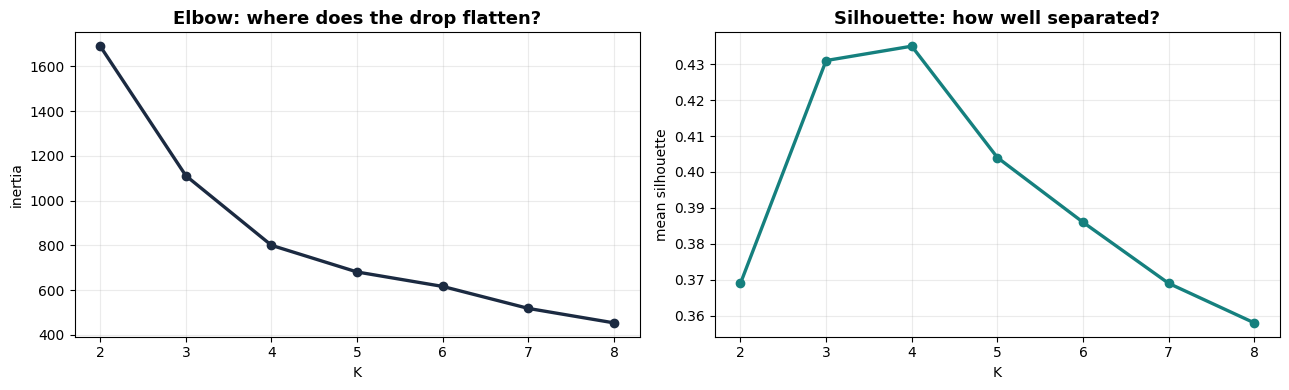

In [9]:
rows = []
for k in range(2, 9):
    m = KMeans(n_clusters=k, n_init=10, random_state=RNG_SEED).fit(X_scaled)
    rows.append({"K": k,
                 "inertia": round(m.inertia_, 1),
                 "silhouette": round(silhouette_score(X_scaled, m.labels_), 3),
                 "smallest cluster": int(np.bincount(m.labels_).min())})
k_table = pd.DataFrame(rows)
print(k_table.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(k_table["K"], k_table["inertia"], marker="o", lw=2.4, color="#1B2A41")
axes[0].set_title("Elbow: where does the drop flatten?", fontsize=13, fontweight="bold")
axes[0].set_xlabel("K"); axes[0].set_ylabel("inertia")
axes[1].plot(k_table["K"], k_table["silhouette"], marker="o", lw=2.4, color="#15807E")
axes[1].set_title("Silhouette: how well separated?", fontsize=13, fontweight="bold")
axes[1].set_xlabel("K"); axes[1].set_ylabel("mean silhouette")
for ax in axes: ax.grid(alpha=.25)
plt.tight_layout(); plt.show()

**Read the two plots together — and notice they don't settle it alone.**

- **Elbow:** the big drops come into K = 3 and K = 4; after 4 the curve flattens. The bend is at **4**.
- **Silhouette:** K = 3 and K = 4 are almost tied (0.431 vs 0.435). The silhouette alone cannot choose between them.
- **Sizes:** at K = 4 the smallest cluster still has 110 customers — a group marketing can actually act on. Push K up and the smallest cluster shrinks fast.

When the metrics come close, **look at the clusters themselves**: the profiles at K = 4 describe four behaviours you can name; at K = 3 two of them are forced together. That is the deciding evidence — and Exercise 6(b) asks you to check it.

> Remember: inertia **always** falls as K rises (at K = 540 it is zero). Never choose the K with the lowest inertia — look for the bend.

---
## Part 6 · Profile, picture, and **name** the segments

A cluster number is not a result. A segment that a marketing team can recognise and act on is.

In [10]:
km_final = KMeans(n_clusters=4, n_init=10, random_state=RNG_SEED).fit(X_scaled)
labels_final = km_final.labels_

prof = profile(labels_final)
channel = pd.crosstab(labels_final, customers["preferred_channel"], normalize="index").round(2)
print(prof.join(channel).to_string())

# z-scores make the profile readable: how far is each cluster from the average customer?
z = (prof[FEATURES] - customers[FEATURES].mean()) / customers[FEATURES].std()
print("\nHow unusual is each cluster? (z-score vs the average customer)")
print(z.round(2).to_string())

          age  annual_income  spend_per_visit  visits_per_month  recency_days  size   app  in-store   web
cluster                                                                                                  
0        41.1        46811.8            428.9               0.6         118.4   110  0.00      0.51  0.49
1        23.7        46815.3            167.1              10.4           5.9   150  0.65      0.35  0.00
2        53.2        47613.6           2165.4               1.4          24.1   118  0.00      0.58  0.42
3        40.9        46089.5            826.5               4.0          10.8   162  0.28      0.40  0.32

How unusual is each cluster? (z-score vs the average customer)
          age  annual_income  spend_per_visit  visits_per_month  recency_days
cluster                                                                      
0        0.18           0.00            -0.56             -0.99          1.89
1       -1.21           0.00            -0.90              1.49   

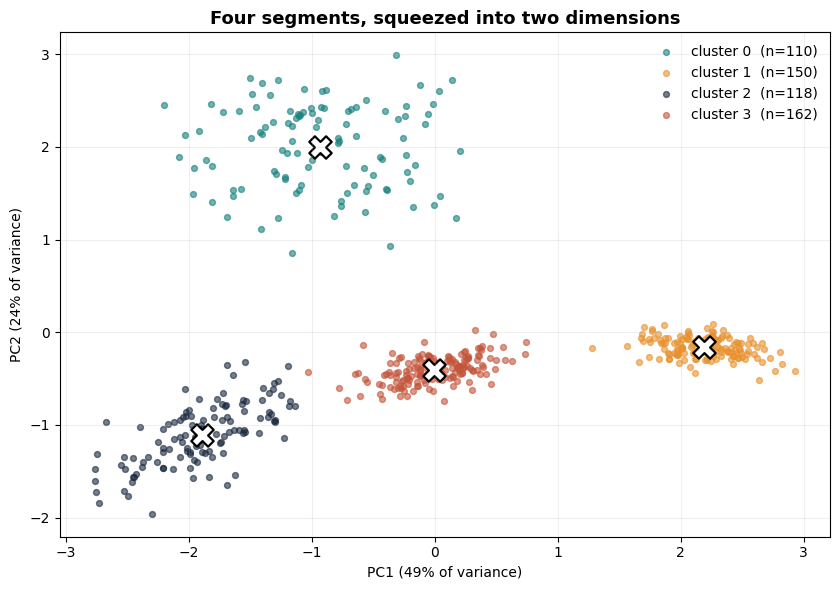

In [11]:
pca = PCA(n_components=2, random_state=RNG_SEED)
P = pca.fit_transform(X_scaled)
centres_2d = pca.transform(km_final.cluster_centers_)

colours = ["#15807E", "#E8912D", "#1B2A41", "#C4553B"]
fig, ax = plt.subplots(figsize=(8.5, 6))
for j in range(4):
    ax.scatter(P[labels_final == j, 0], P[labels_final == j, 1], s=18, alpha=.6,
               color=colours[j], label=f"cluster {j}  (n={np.sum(labels_final == j)})")
ax.scatter(centres_2d[:, 0], centres_2d[:, 1], marker="X", s=260, color="white", edgecolor="black", lw=1.6)
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.0%} of variance)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.0%} of variance)")
ax.set_title("Four segments, squeezed into two dimensions", fontsize=13, fontweight="bold")
ax.legend(frameon=False); ax.grid(alpha=.2); plt.tight_layout(); plt.show()

**Now read the z-score table one row at a time, and give each row a name a manager would understand:**

| what the row shows | a usable name |
|---|---|
| youngest; visits ~10 times a month; small baskets; seen in the last week | **Frequent small-basket regulars** |
| oldest; big baskets (~2,100 baht); about one visit a month | **High-value occasional shoppers** |
| middle-aged; mid-size baskets; about weekly; recent | **Steady mid-spenders** |
| rarely visit; last seen ~4 months ago | **Lapsing customers** — a win-back campaign |

(Your cluster numbers may be in a different order — match by the profile, not the number.)

Notice what is **not** in the table: income. It is flat across all four, so it does not describe any segment. Leaving it in the clustering was harmless once we scaled; leaving it in the *description* would be misleading.

> **The PCA plot is a picture, not proof.** Two components keep about 73% of the variance, so some overlap you see is squashing, not real. Use the plot to communicate; use the profiles to decide.

> **The report sentence you are aiming for:** *"After standardising five behavioural features, K-Means (k-means++, n_init = 10) with K = 4 — supported by the elbow and confirmed by interpretable profiles, although the silhouette could not separate K = 3 from 4 — produced four segments: … . Income did not differ between segments."* That paragraph earns marks. "We found 4 clusters" does not.

---
---
# Exercises (graded)

Replace each `...`, run every ✅ self-check, complete the disclosure. Be ready to explain any line orally.

### Exercise 1 — One iteration, by hand (in NumPy)
The classroom activity, now in code. Six points on a line, K = 2, centroids start at 2 and 5.
- **`labels_1`** — the cluster (0 or 1) of each point after the first **assign** step
- **`mu_new`** — the two centroids after the **update** step
- **`labels_2`** — the clusters after assigning **again** with `mu_new`
- **`converged`** — `True` if `labels_2` is identical to `labels_1`
- **`inertia_before`**, **`inertia_after`** — inertia using `labels_1` with the **starting** centroids, and using `labels_2` with `mu_new`

In [ ]:
x  = np.array([1, 2, 3, 8, 9, 10], dtype=float)
mu = np.array([2.0, 5.0])

labels_1 = ...          # hint: np.abs(x[:, None] - mu[None, :]).argmin(axis=1)
mu_new = ...
labels_2 = ...
converged = ...
inertia_before = ...
inertia_after = ...
print(f'step A: {labels_1} | update: {mu_new} | step C: {labels_2} | converged: {converged}')
print(f'inertia {inertia_before} -> {inertia_after}')

In [ ]:
# ✅ Self-check — Exercise 1
assert list(labels_1) == [0, 0, 0, 1, 1, 1], "Point 3 is 1 from μ₁=2 and 2 from μ₂=5 — it joins cluster 0."
assert np.allclose(mu_new, [2, 9]), "Each centroid moves to the mean of ITS OWN cluster: mean{1,2,3}=2, mean{8,9,10}=9."
assert converged is True, "With centroids 2 and 9 the boundary is 5.5 — nothing crosses it."
assert inertia_before == 52 and inertia_after == 4, "Before: (1+0+1)+(9+16+25)=52. After: (1+0+1)+(1+0+1)=4."
print("Exercise 1 self-check passed ✔")
print(f"  one update moved μ₂ from 5 to 9 and cut inertia from {inertia_before:.0f} to {inertia_after:.0f}")
print("  This is exactly the form of an examination question — you can now check your paper answer in code.")

### Exercise 2 — Prove that scaling changed the story
Using `customers`, `km_raw` and `km_scaled` from Part 2:
- **`top_raw_feature`** — the name of the feature with the largest variance in the **raw** data
- **`top_raw_share`** — that feature's share of the total raw variance (0–1)
- **`raw_income_ratio`** — the highest cluster-mean `annual_income` divided by the lowest, for the **raw** clusters
- **`scaled_income_ratio`** — the same for the **scaled** clusters

In [ ]:
variances = customers[FEATURES].var()
top_raw_feature = ...
top_raw_share = ...
raw_income = customers.assign(c=km_raw.labels_).groupby('c')['annual_income'].mean()
raw_income_ratio = ...
scaled_income = ...
scaled_income_ratio = ...
print(f'{top_raw_feature} holds {top_raw_share:.2%} of the raw variance')
print(f'income ratio across clusters — raw {raw_income_ratio:.2f} | scaled {scaled_income_ratio:.2f}')

In [ ]:
# ✅ Self-check — Exercise 2
assert top_raw_feature == "annual_income", "Which column has by far the biggest numbers?"
assert abs(top_raw_share - customers[FEATURES].var().max() / customers[FEATURES].var().sum()) < 1e-9
assert raw_income_ratio > 1.5, "Raw clusters should be income bands — the richest band earns far more than the poorest."
assert scaled_income_ratio < 1.1, "After scaling, income should be nearly flat across clusters."
print("Exercise 2 self-check passed ✔")
print(f"  raw: one feature carries {top_raw_share:.1%} of the variance, so the clusters are income bands "
      f"(richest/poorest = {raw_income_ratio:.2f}×)")
print(f"  scaled: income is flat ({scaled_income_ratio:.2f}×) — the clusters are about behaviour instead")

### Exercise 3 — Inertia by hand
Inertia is the sum of squared distances from each point to **its own** centroid. Using `km_final` and `X_scaled`:
- **`my_inertia`** — compute it yourself from `km_final.labels_` and `km_final.cluster_centers_` (NumPy only)
- **`never_rises`** — `True` if no value in `history` (Part 3) is larger than the one before it
- **`pct_drop`** — the percentage fall from the first to the last value of `history`

In [ ]:
centres_per_point = km_final.cluster_centers_[km_final.labels_]   # each row's own centroid
my_inertia = ...
never_rises = ...
pct_drop = ...
print(f'my inertia {my_inertia:.2f} | sklearn {km_final.inertia_:.2f}')
print(f'never rises: {never_rises} | fell {pct_drop:.1f}% from first to last iteration')

In [ ]:
# ✅ Self-check — Exercise 3
assert abs(my_inertia - km_final.inertia_) / km_final.inertia_ < 1e-6, \
    "Square the differences, sum over features AND over points."
assert never_rises is True, "Assign and update can each only lower inertia."
assert abs(pct_drop - (history[0] - history[-1]) / history[0] * 100) < 1e-9
print("Exercise 3 self-check passed ✔")
print(f"  your inertia matches sklearn's: {my_inertia:.1f}")
print(f"  Lloyd's loop cut it by {pct_drop:.0f}% and never went up once — that is why K-Means always stops.")

### Exercise 4 — How risky is one random start?
Using `random_inertias` and `pp_inertias` from Part 4:
- **`best`** — the lowest inertia reached by any of the 40 runs
- **`n_random_best`**, **`n_pp_best`** — how many runs of each kind got within 0.1% of `best`
- **`worst_pct`** — how much worse (in %) the worst random start is than `best`

In [ ]:
best = ...
n_random_best = ...
n_pp_best = ...
worst_pct = ...
print(f'best {best:.1f} | reached by {n_random_best}/20 random and {n_pp_best}/20 k-means++')
print(f'worst random start is {worst_pct:.0f}% worse than the best')

In [ ]:
# ✅ Self-check — Exercise 4
_b = min(random_inertias + pp_inertias)
assert abs(best - _b) < 1e-9, "best = the minimum over all 40 runs."
assert n_random_best == sum(v <= _b * 1.001 for v in random_inertias)
assert n_pp_best >= n_random_best, "k-means++ should reach the best answer at least as often as random seeding."
assert n_random_best < 20, "Some random starts should get stuck — that is the whole problem."
print("Exercise 4 self-check passed ✔")
print(f"  {20 - n_random_best} of 20 random starts got stuck, the worst one {worst_pct:.0f}% above the best")
print(f"  k-means++ reached the best in {n_pp_best} of 20 — better, not perfect. Hence n_init = 10.")

### Exercise 5 — Read the K evidence with numbers
Using `k_table` from Part 5:
- **`sil_best_k`** — the K with the highest silhouette
- **`sil_gap_3_4`** — the absolute silhouette difference between K = 3 and K = 4
- **`elbow_k`** — the K where the **drop into K** divided by the **drop out of K** is largest (a simple way to find the bend; only K = 3 … 7 have both drops)
- **`smallest_at_8`** — the size of the smallest cluster at K = 8

In [ ]:
t = k_table.set_index('K')
sil_best_k = ...
sil_gap_3_4 = ...
drop_into = -t['inertia'].diff()            # drop_into[k] = inertia(k-1) - inertia(k)
drop_out  = drop_into.shift(-1)             # drop_out[k]  = inertia(k) - inertia(k+1)
elbow_ratio = (drop_into / drop_out).dropna()
elbow_k = ...
smallest_at_8 = ...
print(f'silhouette picks K={sil_best_k} (gap 3 vs 4 = {sil_gap_3_4:.3f}) | elbow at K={elbow_k} | smallest cluster at K=8: {smallest_at_8}')

In [ ]:
# ✅ Self-check — Exercise 5
_t = k_table.set_index("K")
assert sil_best_k == int(_t["silhouette"].idxmax())
assert sil_gap_3_4 < 0.02, "K=3 and K=4 should be nearly tied on silhouette."
assert elbow_k == 4, "The drop into 4 is large, the drop out of 4 is small — that is the bend."
assert smallest_at_8 < int(_t.loc[4, "smallest cluster"]), "More clusters → smaller groups."
print("Exercise 5 self-check passed ✔")
print(f"  elbow says {elbow_k}; silhouette says {sil_best_k}, but only by {sil_gap_3_4:.3f} over K=3")
print(f"  at K=8 the smallest group has just {smallest_at_8} customers")
print("  Two metrics, one near-tie: the profiles and the business use decide. That is normal, not failure.")

### Exercise 6 — Open-ended: one honest investigation
Pick **one**, carry it out properly (fixed `random_state`, `n_init=10`, scaled data), and write it up:

**(a)** **Outliers grab centroids.** Add 5 extreme customers to the data (for example `spend_per_visit` = 25,000 baht and `visits_per_month` = 20), refit K = 4 on the re-scaled data, and look at the cluster sizes and profiles. Did a centroid get spent on the outliers — and which two real segments were merged to pay for it?

**(b)** **K = 3 or K = 4?** Fit K = 3, profile it, and compare it with the K = 4 profiles from Part 6. Which two segments merge at K = 3? Write the one-sentence business argument for each choice, and say which you would recommend.

**(c)** **Are the clusters stable?** Draw 10 bootstrap resamples of the customers, refit K = 4 on each, and use `adjusted_rand_score` to compare each resample's labels with `labels_final` on the same rows. Repeat for K = 6. Which K gives the more stable segments, and what does that suggest?

Then write **3+ sentences**: what you did, what you found, and one caveat about what your evidence does *not* establish.

In [ ]:
# your investigation here — (a), (b) or (c)
...

*Your write-up (≥ 3 sentences): what you did · what you found · one caveat.*

✍️ ...

---
## 🧾 AI-usage disclosure (required)

> **AI tools used:** *e.g., "Claude — explained why inertia can never increase; helped debug the pandas `diff()` in Exercise 5" — or — "None."*
>
> **Written and understood by:** *your name & student ID*
>
> I can explain every line of code in this notebook.

## 📤 Submitting

1. **Runtime → Restart session and run all** — clean run, every self-check *passed*.
2. Disclosure filled, notebook renamed `Lab9_<student_id>`.
3. **File → Download → .ipynb** → upload to the MSTeam.

---
*Dataset: retail customers (synthetic, generated in this notebook with a fixed seed).*